In [ ]:
## Experiment performed by:
## Aman Tyagi 23/CS/046

### Pre-Processing (Dataset and Setup)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Mall_Customers.xls')

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [23]:
print(df.shape)


(200, 5)


In [24]:

print(df.columns)


Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


In [25]:

print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    int32
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int32(1), int64(4)
memory usage: 7.2 KB
None


In [26]:
print(df.describe())


       CustomerID      Gender         Age  Annual Income (k$)  \
count  200.000000  200.000000  200.000000          200.000000   
mean   100.500000    0.440000   38.850000           60.560000   
std     57.879185    0.497633   13.969007           26.264721   
min      1.000000    0.000000   18.000000           15.000000   
25%     50.750000    0.000000   28.750000           41.500000   
50%    100.500000    0.000000   36.000000           61.500000   
75%    150.250000    1.000000   49.000000           78.000000   
max    200.000000    1.000000   70.000000          137.000000   

       Spending Score (1-100)  
count              200.000000  
mean                50.200000  
std                 25.823522  
min                  1.000000  
25%                 34.750000  
50%                 50.000000  
75%                 73.000000  
max                 99.000000  


In [4]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

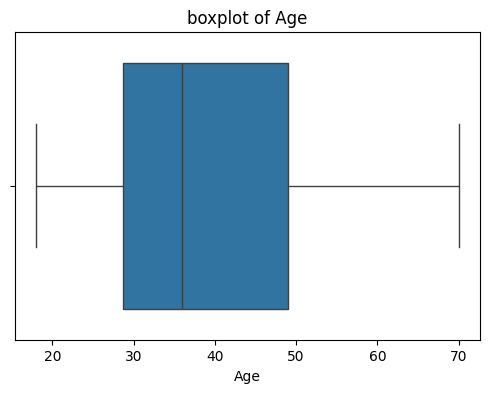

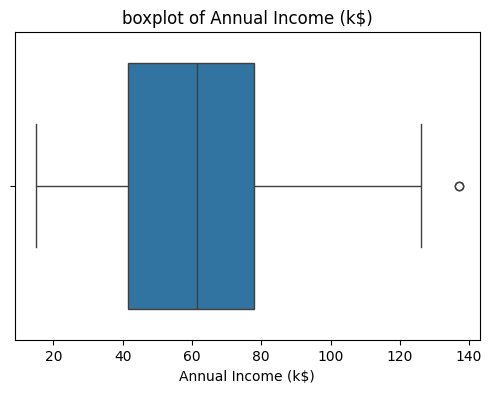

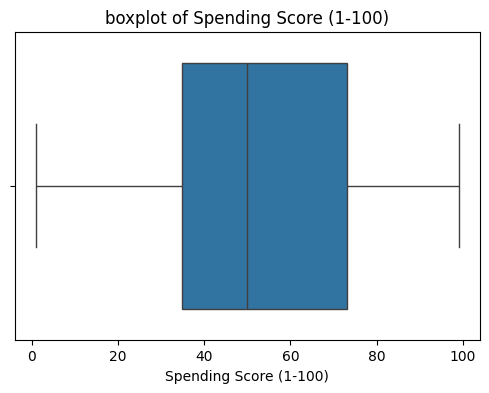

In [5]:
numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

for col in numeric_cols:
  plt.figure(figsize=(6, 4))
  sns.boxplot(x=df[col])
  plt.title(f'boxplot of {col}')
  plt.show()


In [6]:
## encoding the features
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [28]:
from sklearn.preprocessing import MinMaxScaler

# Separate identifier column
customer_ids = df['CustomerID'].copy()

# Select only numerical features (in case there are non-numeric columns)
features = df.drop(columns=['CustomerID']).select_dtypes(include=['number']).copy()

# Initialize and apply MinMaxScaler
scaler = MinMaxScaler()
features_scaled = pd.DataFrame(
    scaler.fit_transform(features),
    columns=features.columns,
    index=features.index
)

# Combine the scaled features back with the CustomerID column
df_scaled = pd.concat([customer_ids, features_scaled], axis=1)


In [29]:
df_scaled.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1.0,0.019231,0.000000,0.387755
1,2,1.0,0.057692,0.000000,0.816327
2,3,0.0,0.038462,0.008197,0.051020
3,4,0.0,0.096154,0.008197,0.775510
4,5,0.0,0.250000,0.016393,0.397959


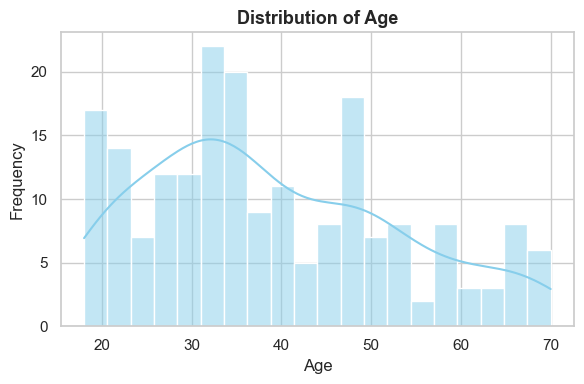

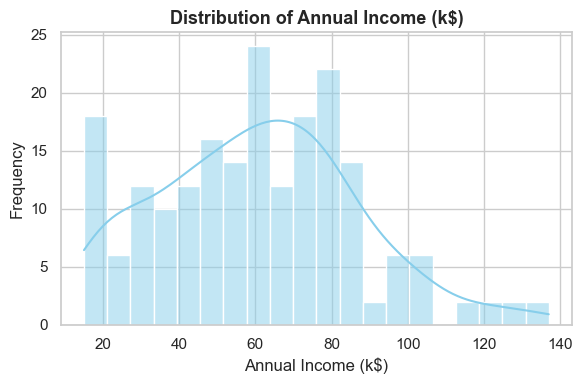

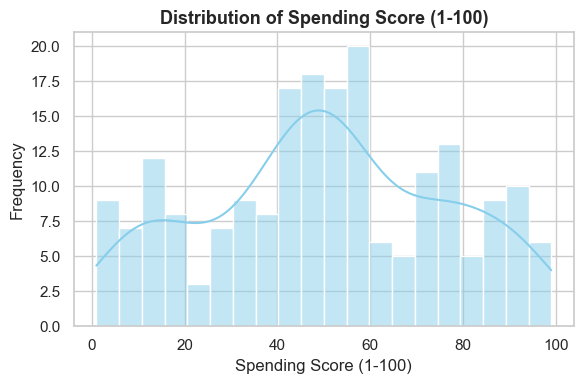

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the numeric columns to visualize
cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# Set a consistent plotting style
sns.set(style="whitegrid")

# Plot distributions for each numeric feature
for col in cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=20, color='skyblue')
    plt.title(f"Distribution of {col}", fontsize=13, weight='bold')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


## Implementing K-means from scratch

In [10]:
## initialisation

def initialize_centroids(X, k, random_state=None):
  if random_state is not None:
    np.random.seed(random_state)

  n_samples = X.shape[0]
  random_indices = np.random.choice(n_samples, size =k, replace=False)

  centroids = X[random_indices]

  return centroids

In [11]:
def initialise_centroids_kmeanspp(X, k, random_state=None):
  if random_state is not None:
    np.random.seed(random_state)

  n_samples, n_features = X.shape

  first_centroid_idx = np.random.randint(n_samples)
  centroids = X[first_centroid_idx]

  for _ in range (1, k):
    distances = np.array([
        min(np.linalg.norm(x -c)**2 for c in centroids) for x in X
    ])

    probabilities = distances/ distances.sum()

    next_centroid_idx = np.random.choice(n_samples, p=probabilities)
    centroids.append(X[next_centroid_idx])

  return np.array(centroids)


In [12]:
## assignment

def assign_clusters(X, centroids):
  labels = []

  for x in X:
    distances = []

    for c in centroids:
      distance = np.linalg.norm(x - c)
      distances.append(distance)

    label = np.argmin(distances)
    labels.append(label)

  return np.array(labels)

In [13]:
def update_centroids(X, labels, k):
  new_centroids = []

  for i in range(k):
    points_in_cluster = X[labels == i]

    if len(points_in_cluster) > 0 :
      new_centroid = points_in_cluster.mean(axis=0)
      new_centroids.append(new_centroid)
    else:
      new_centroid = np.zeros(X.shape[1])
      new_centroids.append(new_centroid)

  return np.array(new_centroids)

In [14]:
## main algorithm loop

def kmeans(X, k, max_iters=100, tol=1e-4, random_state=None):
  if random_state is not None:
    np.random.seed(random_state)

  n_samples, n_features = X.shape
  centroids = initialize_centroids(X, k, random_state)

  for i in range(max_iters):
      labels = assign_clusters(X, centroids)

      new_centroids = update_centroids(X, labels, k)

      shift = np.linalg.norm(new_centroids - centroids)

      if shift < tol:
          break

      centroids = new_centroids


  distances = []
  for idx, x in enumerate(X):
      c = centroids[labels[idx]]
      distances.append(np.linalg.norm(x - c) ** 2)
  inertia = np.sum(distances)

  return centroids, labels, i + 1, inertia

In [15]:
## elbow method and silhouette score
## just importing silhouetter score from sklearn
from sklearn.metrics import silhouette_score

def evaluate_k_range(X, k_min=2, k_max = 10, random_state=None):
  intertias = []
  silhouettes = []

  for k in range(k_min, k_max+1):
    centroids, labels, iter, inertia = kmeans(X, k, random_state=random_state)
    intertias.append(inertia)

    if len(set(labels)) > 1:
      sil = silhouette_score(X, labels)
    else:
      sil = np.nan
    silhouettes.append(sil)

    print(f"k={k}: inertia={inertia:.3f}, silhouetter={sil:.3f}")


  results = pd.DataFrame({
      "k": range(k_min, k_max+1),
      "inertia": intertias,
      "silhouette": silhouettes
  })

  fig, ax1 = plt.subplots(figsize=(8,5))

  color = 'tab:blue'
  ax1.set_xlabel("Number of Clusters (k)")
  ax1.set_ylabel("Inertia", color=color)
  ax1.plot(results["k"], results["inertia"], marker='o', color=color)
  ax1.tick_params(axis='y', labelcolor=color)
  ax1.set_title("Elbow Method and Silhouette Score")

  ax2 = ax1.twinx()
  color = 'tab:orange'
  ax2.set_ylabel("Silhouette Score", color=color)
  ax2.plot(results["k"], results["silhouette"], marker='s', linestyle='--', color=color)
  ax2.tick_params(axis='y', labelcolor=color)

  plt.show()

  return results

k=2: inertia=166780.410, silhouetter=0.623
k=3: inertia=74213.691, silhouetter=0.583
k=4: inertia=41852.567, silhouetter=0.562
k=5: inertia=27126.958, silhouetter=0.548
k=6: inertia=18954.075, silhouetter=0.537
k=7: inertia=13820.293, silhouetter=0.530
k=8: inertia=11110.321, silhouetter=0.522
k=9: inertia=8657.719, silhouetter=0.517
k=10: inertia=7258.446, silhouetter=0.512


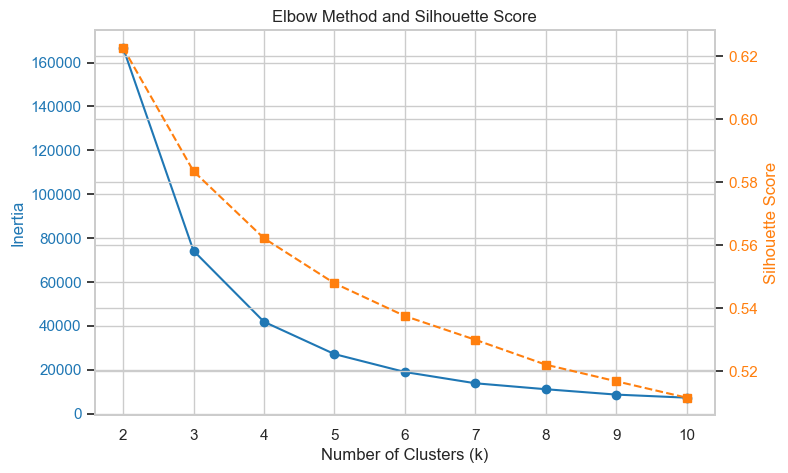

    k        inertia  silhouette
0   2  166780.410051    0.622640
1   3   74213.691158    0.583402
2   4   41852.567134    0.562121
3   5   27126.957987    0.547831
4   6   18954.074837    0.537433
5   7   13820.292996    0.529888
6   8   11110.321129    0.521980
7   9    8657.718922    0.516713
8  10    7258.446403    0.511504


In [31]:
## applying the algorithmm
X = df_scaled.values
results = evaluate_k_range(X, k_min=2, k_max=10, random_state=43)

print(results)


In [32]:
chosen_k = 3

centroids, labels, n_iter, inertia = kmeans(X, k=chosen_k,max_iters=100, tol=0.0001, random_state=42)

print("Final centroids:\n", centroids)
print("Inertia:", inertia)
print("Iterations:", n_iter)

Final centroids:
 [[1.66500000e+02 4.55882353e-01 3.47002262e-01 6.05834137e-01
  5.02100840e-01]
 [3.30000000e+01 4.00000000e-01 3.95266272e-01 1.34300126e-01
  5.00313972e-01]
 [9.90000000e+01 4.62686567e-01 4.61251435e-01 3.69586494e-01
  5.03655193e-01]]
Inertia: 74213.69115772538
Iterations: 14


In [33]:
df_scaled["cluster"] = labels

In [34]:
cluster_means = df_scaled.groupby("cluster").mean()
print(cluster_means)


         CustomerID    Gender       Age  Annual Income (k$)  \
cluster                                                       
0             166.5  0.455882  0.347002            0.605834   
1              33.0  0.400000  0.395266            0.134300   
2              99.0  0.462687  0.461251            0.369586   

         Spending Score (1-100)  
cluster                          
0                      0.502101  
1                      0.500314  
2                      0.503655  


Cluster 0: Average-age, middle-income customers with moderate spending behavior.

Cluster 1: Younger, low-income customers who spend moderately

Cluster 2: Older, mid-income customers who spend consistently

Cluster 3: Younger, high-income customers with average spending levels

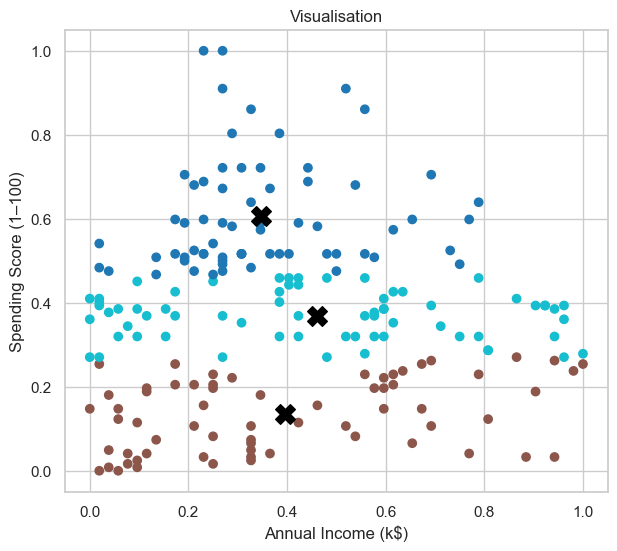

In [35]:
plt.figure(figsize=(7,6))
plt.scatter(df_scaled.iloc[:, 2], df_scaled.iloc[:, 3], c=labels, cmap='tab10')
plt.scatter(centroids[:, 2], centroids[:, 3], c='black', marker='X', s=200)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1–100)')
plt.title('Visualisation')
plt.show()


In [21]:
from sklearn.cluster import KMeans


# Run sklearn KMeans
sk_kmeans = KMeans(
    n_clusters=chosen_k,
    max_iter=100,
    tol=1e-4,
    random_state=42
)

sk_kmeans.fit(X)

sk_centroids = sk_kmeans.cluster_centers_
sk_inertia = sk_kmeans.inertia_
sk_iters = sk_kmeans.n_iter_

print("scikit-learn KMeans Results:")
print(f"Final Inertia: {sk_inertia:.4f}")
print(f"Iterations until convergence: {sk_iters}")
print(f"Centroids:\n{sk_centroids}")


scikit-learn KMeans Results:
Final Inertia: 41752.4717
Iterations until convergence: 6
Centroids:
[[7.45000000e+01 4.40000000e-01 5.08461538e-01 2.97540984e-01
  5.02448980e-01]
 [1.75500000e+02 4.60000000e-01 3.71538462e-01 6.46885246e-01
  4.99591837e-01]
 [2.50000000e+01 3.67346939e-01 3.33987441e-01 9.95316159e-02
  4.96251562e-01]
 [1.25000000e+02 4.90196078e-01 3.88763198e-01 4.42944391e-01
  5.09603842e-01]]


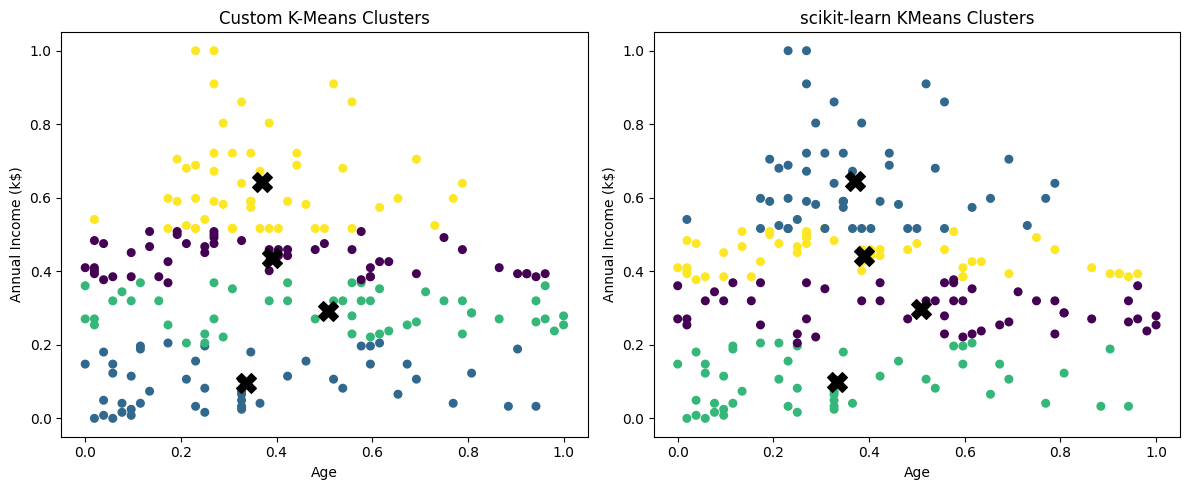

In [22]:

centroids_custom, labels_custom, n_iter_custom, inertia_custom = kmeans(
    X, k=chosen_k, max_iters=100, tol=1e-4, random_state=42
)

sk_kmeans = KMeans(n_clusters=chosen_k, max_iter=100, tol=1e-4, random_state=42)
sk_kmeans.fit(X)
labels_sk = sk_kmeans.labels_
centroids_sk = sk_kmeans.cluster_centers_

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x_idx, y_idx = 2, 3

# Custom K-Means plot
axes[0].scatter(X[:, x_idx], X[:, y_idx], c=labels_custom, cmap='viridis', s=30)
axes[0].scatter(centroids_custom[:, x_idx], centroids_custom[:, y_idx], c='black', marker='X', s=200)
axes[0].set_title("Custom K-Means Clusters")
axes[0].set_xlabel(df_scaled.columns[x_idx])
axes[0].set_ylabel(df_scaled.columns[y_idx])

# scikit-learn K-Means plot
axes[1].scatter(X[:, x_idx], X[:, y_idx], c=labels_sk, cmap='viridis', s=30)
axes[1].scatter(centroids_sk[:, x_idx], centroids_sk[:, y_idx], c='black', marker='X', s=200)
axes[1].set_title("scikit-learn KMeans Clusters")
axes[1].set_xlabel(df_scaled.columns[x_idx])
axes[1].set_ylabel(df_scaled.columns[y_idx])

plt.tight_layout()
plt.show()